# Volume change on shelf over time, ACCESS-OM2-01

This notebook is incomplete, because I haven't run the daily data for ACCESS-OM2-01 yet.

In [36]:
import glob
import dask.distributed as dsk
import matplotlib.pyplot as plt
import xarray as xr
import cf_xarray as cfxr
import numpy as np
import xesmf as xe
from matplotlib.colors import to_rgba

import cmocean as cm
import cartopy.crs as ccrs

import cartopy.feature as cft
import matplotlib.path as mpath

import warnings # ignore these warnings
warnings.filterwarnings("ignore", category = FutureWarning)
warnings.filterwarnings("ignore", category = UserWarning)
warnings.filterwarnings("ignore", category = RuntimeWarning)

In [37]:
lat_slice = slice(-79,-59)

# Importing data
paths_C = np.sort(glob.glob('/scratch/x77/kc5856/access-om2/archive/01deg_jra55v13_ryf9091_21mbath_daily-fc7aefa1/output000/ocean/ocean_daily.nc'))
paths_M = np.sort(glob.glob('/scratch/x77/kc5856/access-om2/archive/access-ssp126-sofia_daily-expt-3deaf0e1/output000/ocean/ocean_daily.nc'))

In [38]:
paths_M

array(['/scratch/x77/kc5856/access-om2/archive/access-ssp126-sofia_daily-expt-3deaf0e1/output000/ocean/ocean_daily.nc'],
      dtype='<U109')

In [59]:
# Time variant variables
def preprocess(ds):
    ds = ds[['dzt','salt_tendency']].sel(yt_ocean=lat_slice)
    return ds

data_C = xr.open_mfdataset(paths_C, preprocess = preprocess, chunks = 'auto')
data_M = xr.open_mfdataset(paths_M, preprocess = preprocess, chunks = 'auto')

In [60]:
# Shelf mask

def shelf_mask_isobath(var, model_dict):

    paths = {
             "mom5": "/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz",
             "mom6_01": "/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_01deg.nc",
            "mom6_005": "/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_005deg.nc"
             }

    var = var.cf.sel({'latitude': slice(-90, -59)})

    if paths[model_dict][-3:] == '.nc':
        shelf_mask = xr.open_dataset(paths[model_dict])['contour_masked_above']
    else:
        contour_file = np.load(paths[model_dict])
        shelf_mask = xr.DataArray(contour_file['contour_masked_above'],
                                  coords = var.coords, 
                                  dims = var.dims,
                                  name = 'contour_masked_above')
    
    shelf_mask = xr.where(shelf_mask == 0, 1, 0)
    masked_var = var * shelf_mask
    
    return masked_var, shelf_mask

In [61]:
depth = xr.open_dataset('/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath/output012/ocean/ocean_grid.nc')['ht']
land_mask = (0 * depth).fillna(1)
land = xr.where(np.isnan(depth.rename('land_1')), 1, np.nan)
depth_shelf, shelf_mask = shelf_mask_isobath(depth, 'mom5')

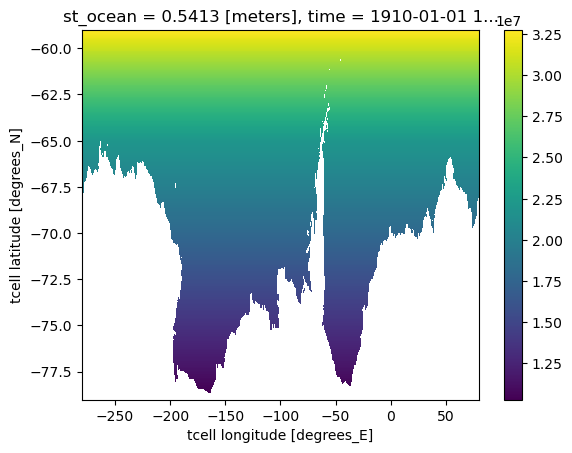

In [63]:
# Doing spatial average
area = xr.open_dataset('/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath/output012/ocean/ocean_grid.nc')['area_t']
var = data_C.salt_tendency.isel(time=0).isel(st_ocean=0)
area_corr = area*(var*0 +1)
area_corr.plot()

In [64]:
# Salinity variable
vol_C = (area_corr * data_C.dzt).where(shelf_mask == 1)
vol_M = (area_corr * data_M.dzt).where(shelf_mask == 1)

In [65]:
# Spatial average
shelf_area = area_corr.where(shelf_mask == 1).sum(['xt_ocean', 'yt_ocean'])

vol_C_time = (area_corr * vol_C).sum(['xt_ocean', 'yt_ocean']) / shelf_area
vol_M_time = (area_corr * vol_M).sum(['xt_ocean', 'yt_ocean']) / shelf_area

In [66]:
vol_C_time

<xarray.DataArray (time: 3, st_ocean: 75)> Size: 900B
dask.array<truediv, shape=(3, 75), dtype=float32, chunksize=(2, 38), chunktype=numpy.ndarray>
Coordinates:
  * time      (time) object 24B 1910-01-01 12:00:00 ... 1910-01-03 12:00:00
  * st_ocean  (st_ocean) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03

In [73]:
vol_C_time = vol_C_time.load()
vol_M_time = vol_M_time.load()

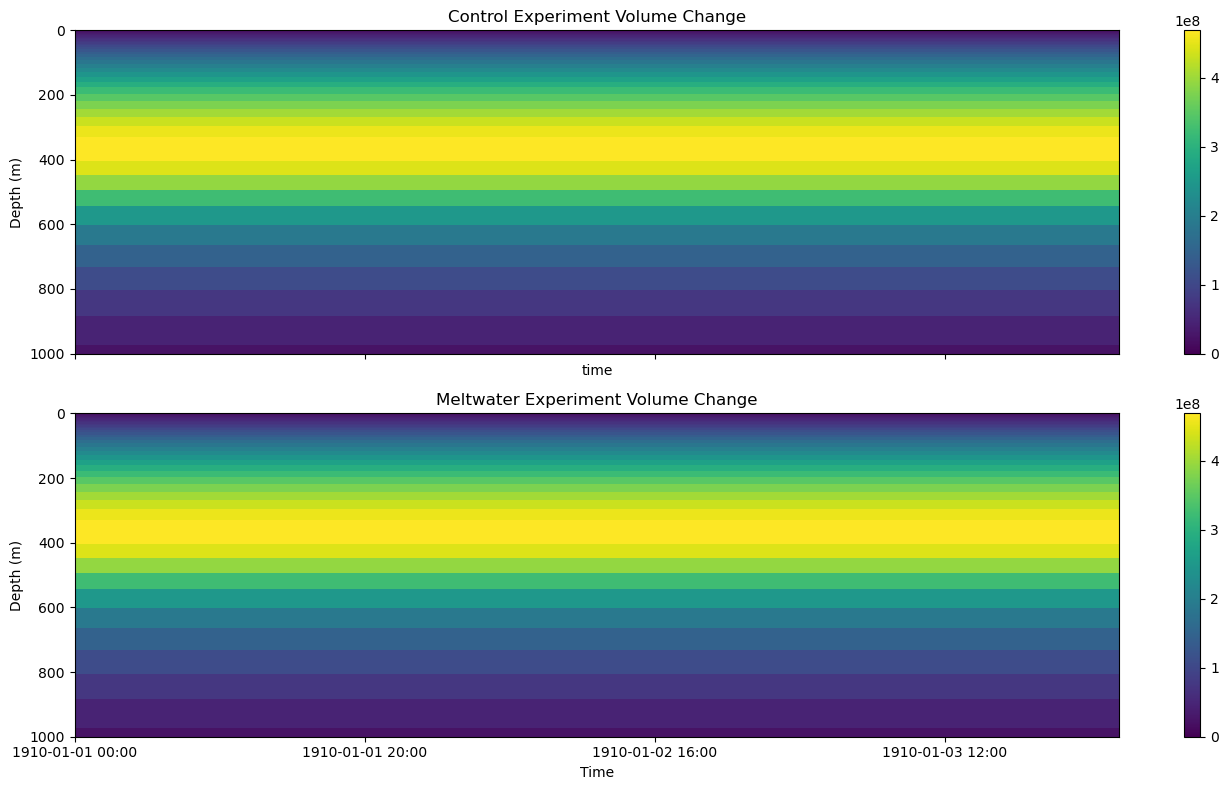

In [79]:
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Control experiment
vol_C_time.plot(ax=axs[0], y='st_ocean', cmap='viridis')
axs[0].set_ylabel('Depth (m)')
axs[0].set_ylim(0,1000)
axs[0].invert_yaxis()
axs[0].set_title('Control Experiment Volume Change')

# Meltwater experiment
vol_M_time.plot(ax=axs[1], y='st_ocean', cmap='viridis')
axs[1].set_ylabel('Depth (m)')
axs[1].set_ylim(0,1000)
axs[1].invert_yaxis()
axs[1].set_title('Meltwater Experiment Volume Change')

axs[1].set_xlabel('Time')

plt.tight_layout()
plt.show()

In [80]:
# Anomaly
vol_anom_time = vol_M_time - vol_C_time
vol_anom_time = vol_anom_time.load()

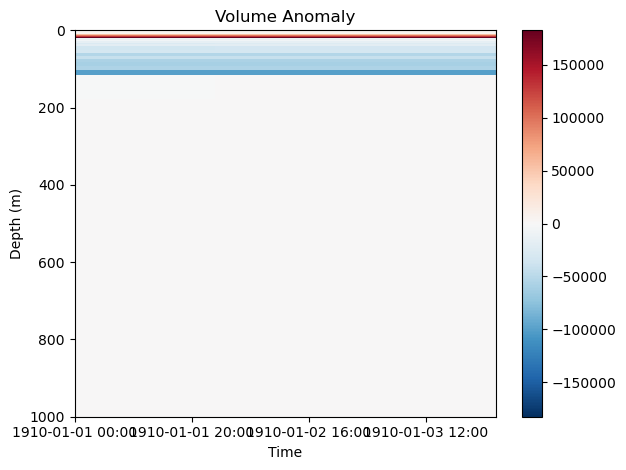

In [81]:
vol_anom_time.plot(y='st_ocean', cmap='RdBu_r')
plt.ylabel('Depth (m)')
plt.ylim(0,1000)
plt.title('Volume Anomaly')
plt.gca().invert_yaxis()
plt.xlabel('Time')
plt.tight_layout()
plt.show()

Okay so we see that volume is changing, mostly around 300m depth. Is there a better way to present this information? This plot is a bit rough.

In [69]:
vol_C_column = vol_C_time.sum('st_ocean')
vol_M_column = vol_M_time.sum('st_ocean')

I don't think I need to thickness-weight this because volcello should already account for that?

In [70]:
vol_anom_column = vol_M_column - vol_C_column

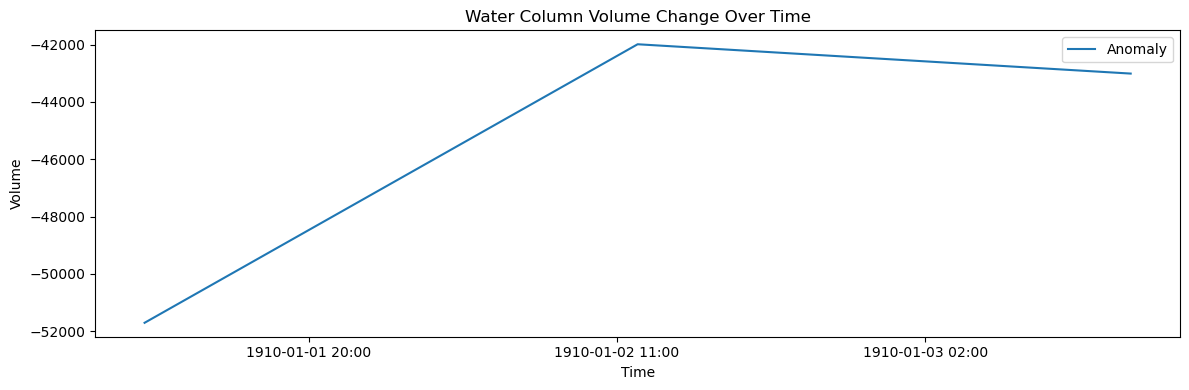

In [82]:
plt.figure(figsize=(12, 4))

# vol_C_column.plot(label='Control')
# vol_M_column.plot(label='Meltwater')
vol_anom_column.plot(label='Anomaly')

plt.legend()
plt.ylabel('Volume')
plt.xlabel('Time')
plt.title('Water Column Volume Change Over Time')
plt.tight_layout()
plt.show()